# BGL Anomaly Detection: DeepSVDD + Self-Reflective RAG Pipeline

**Experiment:** E10 — Two-stage pipeline combining Deep SVDD detection with Self-Reflective RAG.
**Dataset:** BGL
**Stage 1 — Detection:** Deep SVDD (`all-MiniLM-L6-v2` embeddings, hypersphere one-class model)
**Stage 2 — Enrichment:** Vanilla Dense RAG with iterative self-critique and revision (up to 2 reflections)
**Embedding model (RAG):** `BAAI/bge-base-en-v1.5`
**Generation model:** `llama-3.1-8b-instant` via Groq API
**Evaluation model:** `qwen/qwen3-32b` via Groq API (LLM-as-judge)
**Vector store:** Qdrant (persistent, shared KB)
**References:** E09 (DeepSVDD + Hybrid RAG), E06 (Direct Self-Reflective RAG)

## Routing table

| Route | Condition | RAG action |
|---|---|---|
| `clearly_normal` | SVDD distance < P70(val) | SVDD-only, no LLM call |
| `uncertain` | P70 ≤ distance ≤ threshold × 1.10 | Self-Reflective RAG classifies |
| `clearly_anomalous` | distance > threshold × 1.10 | Label forced Anomalous; Self-Reflective RAG provides RCA |

## Self-reflection strategy

After each initial inference pass (Stages B/C), if model confidence < 0.75 or the
response fails to parse, up to 2 self-critique turns are executed.  Each turn passes
the log, retrieved context, SVDD signal, and prior response back to the model for
targeted revision.  `n_reflections`, `initial_label`, and `label_changed` are
tracked per sample for analysis.


In [1]:
# =============================================================================
# CELL 1 - PACKAGE INSTALLATION
# =============================================================================
import subprocess
import sys


def install_packages(pkgs):
    for p in pkgs:
        print(f"Installing: {p}")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "-q"],
            capture_output=True, text=True,
        )
        print("  OK" if r.returncode == 0 else f"  WARN: {r.stderr[:120]}")


install_packages([
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "torch", "sentence-transformers",
    "groq", "tqdm", "qdrant-client",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: torch
  OK
Installing: sentence-transformers
  OK
Installing: groq
  OK
Installing: tqdm
  OK
Installing: qdrant-client
  OK

All packages ready.


  Prompts dir : c:\Users\Abhishek Mulay\Desktop\UpgradAIML\Masters\Topics\Revised_Topics\Topic 1\LogSense\Implementation\Experiments\src\Prompts
  Dataset               : BGL
  SVDD embed model      : all-MiniLM-L6-v2
  LLM model             : llama-3.1-8b-instant
  Eval model            : qwen/qwen3-32b
  Device                : cpu
  Test normal cap       : 200
  Test anomaly cap      : 15
  Retrieval K (logs)    : 5
  Retrieval K (knowl.)  : 2 / collection
  Retrieval K (roles)   : 2 / collection
  Max reflections       : 2
  Reflection conf. thr. : 0.75
  Normal confidence pct : 70th percentile of val distances
  Upper band margin     : +10% of threshold
  Primary Groq keys     : 5  | Fallback: 5

Loading BGL structured log ...
  Rows: 2000,  Normal: 1857,  Anomalous: 143

Creating splits ...
  SVDD train  :   1239  normals
  SVDD val    :    413  normals  (threshold calibration)
  Test Normal :    200  (93.0%)
  Test Anomal :     15  (7.0%)
  Test Total  :    215

Loading SVDD emb

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1821.48it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384

Encoding SVDD train set (1239 samples) ...


Batches: 100%|██████████| 20/20 [00:09<00:00,  2.00it/s]


Encoding SVDD val set (413 samples) ...


...

  [rate-limit] Rotated to fallback (attempt 1)


RAG Evaluation:  67%|██████▋   | 10/15 [12:00<06:02, 72.50s/it]

  [rate-limit] All keys exhausted - sleeping 60s


RAG Evaluation: 100%|██████████| 15/15 [18:19<00:00, 73.32s/it]



  RETRIEVAL METRICS  [BGL]  (n=15)
  MRR                   : 1.0000
  Hit Rate @5           : 1.0000
  Context Precision     : 1.0000

  RAGAs METRICS
  Faithfulness          : 0.3867
  Answer Relevance      : 0.8600
  Context Precision     : 1.0000
  Context Recall        : 1.0000

  ADDITIONAL RAG METRICS
  Root Cause Score      : 0.9833
  Evidence Support      : 0.4987
  Severity Agreement    : 1.0000
  Consistency Score     : 1.0000
  Role Appr. (SRE)      : 0.6000
  Role Appr. (DevOps)   : 0.5733
  Completeness Score    : 0.9733


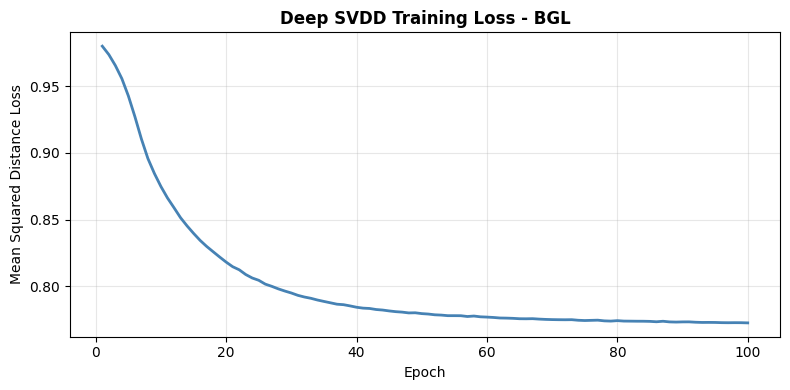

  Saved: bgl_svdd_self_ref_rag_svdd_training_loss.png


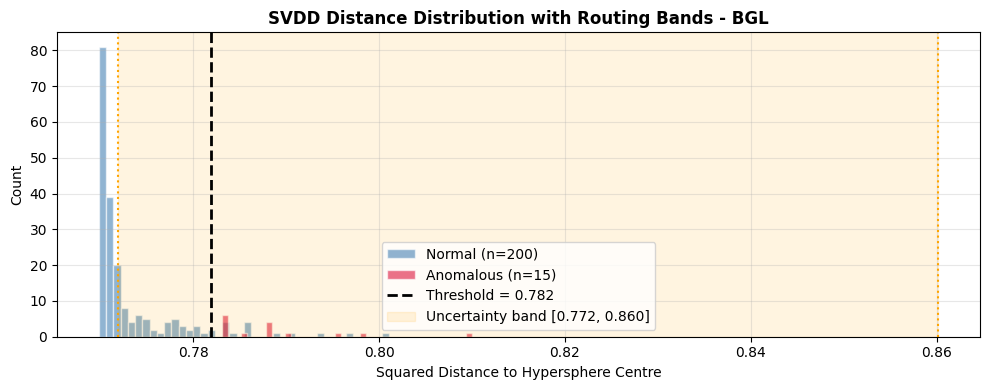

  Saved: bgl_svdd_self_ref_rag_svdd_distance_dist.png


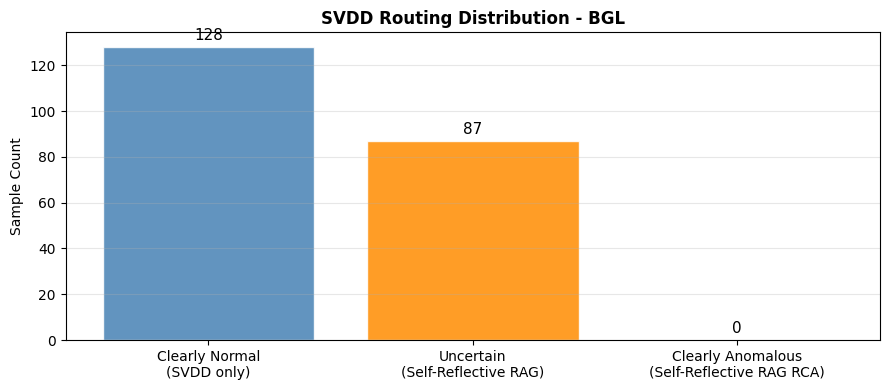

  Saved: bgl_svdd_self_ref_rag_routing_dist.png


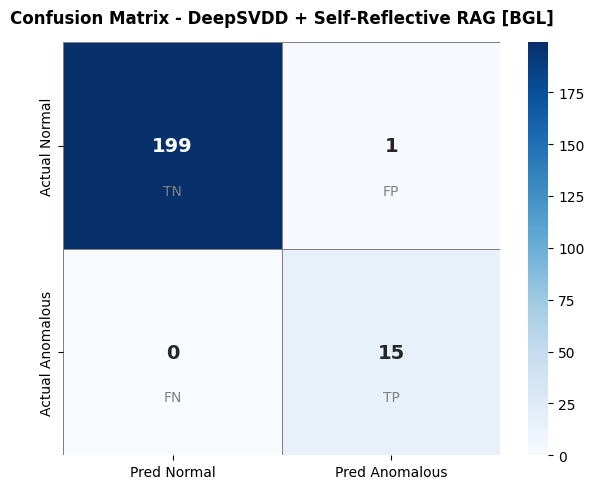

  Saved: bgl_svdd_self_ref_rag_confusion_matrix.png


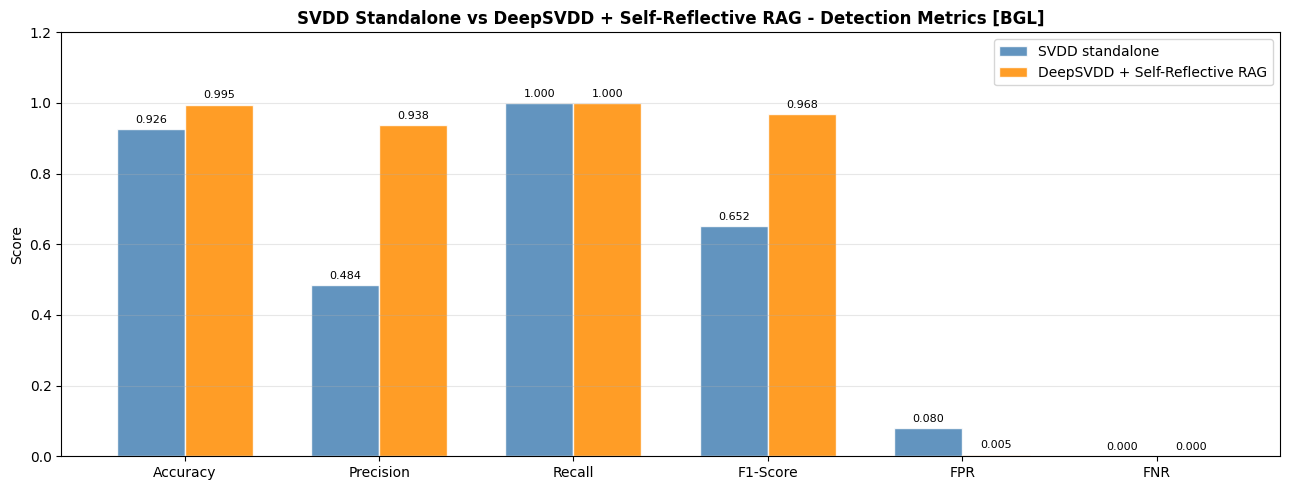

  Saved: bgl_svdd_self_ref_rag_detection_metrics.png


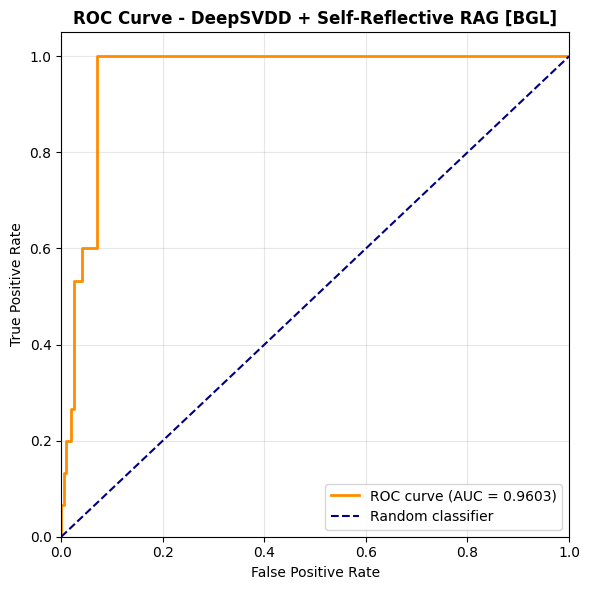

  Saved: bgl_svdd_self_ref_rag_roc_curve.png


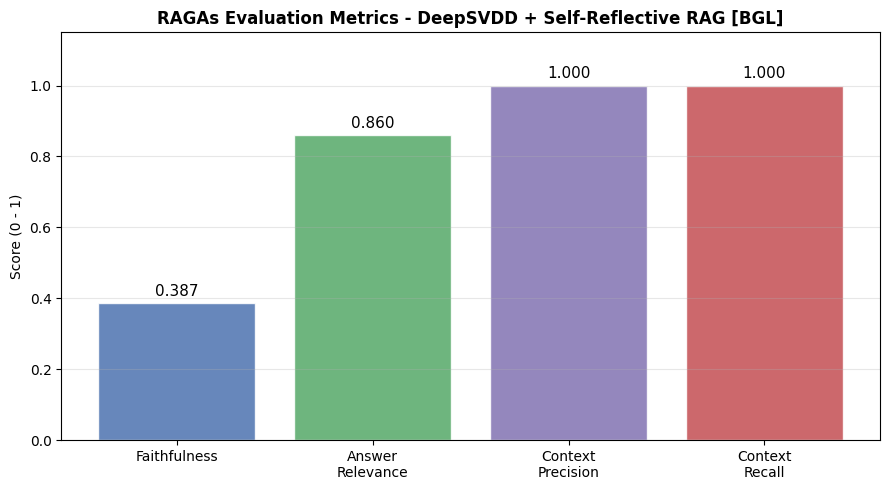

  Saved: bgl_svdd_self_ref_rag_ragas_metrics.png


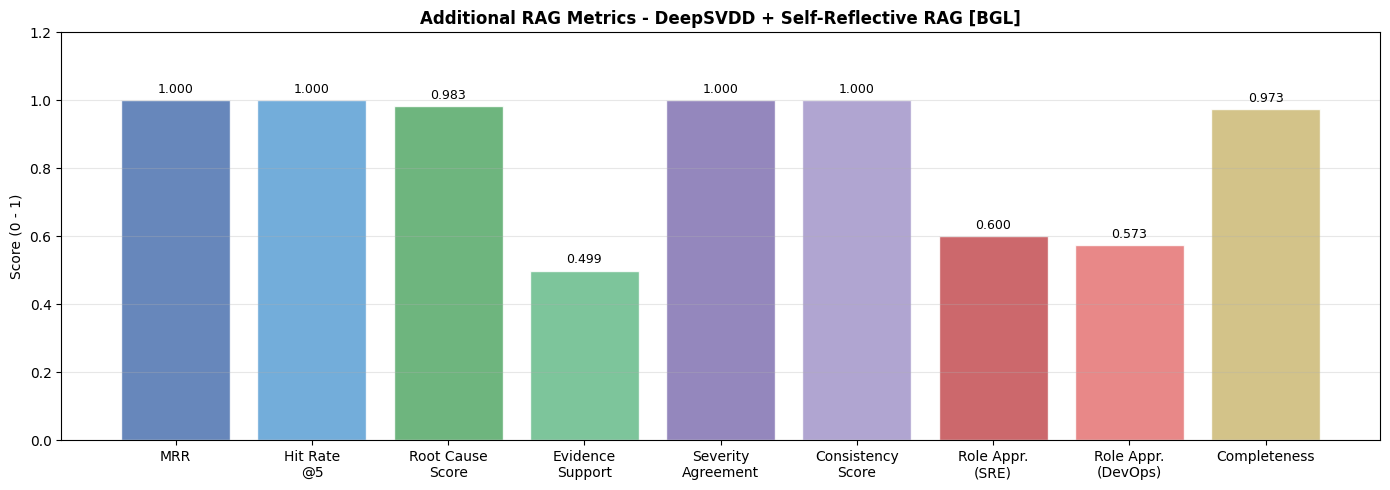

  Saved: bgl_svdd_self_ref_rag_additional_rag_metrics.png


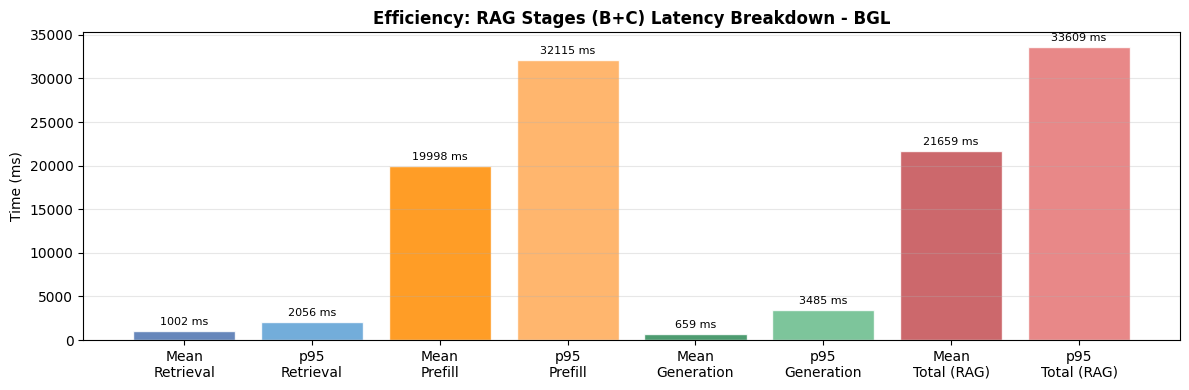

  Saved: bgl_svdd_self_ref_rag_latency_breakdown.png


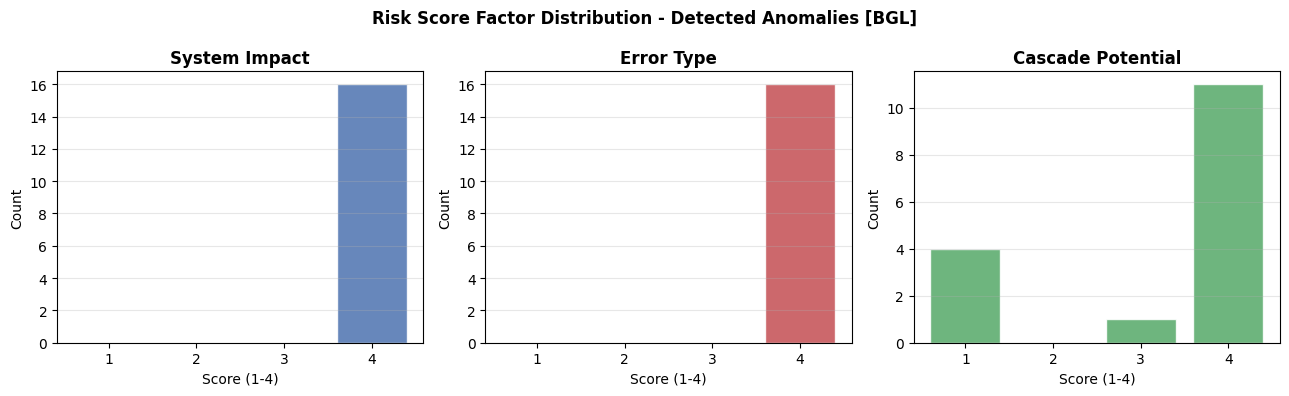

  Saved: bgl_svdd_self_ref_rag_risk_score_dist.png


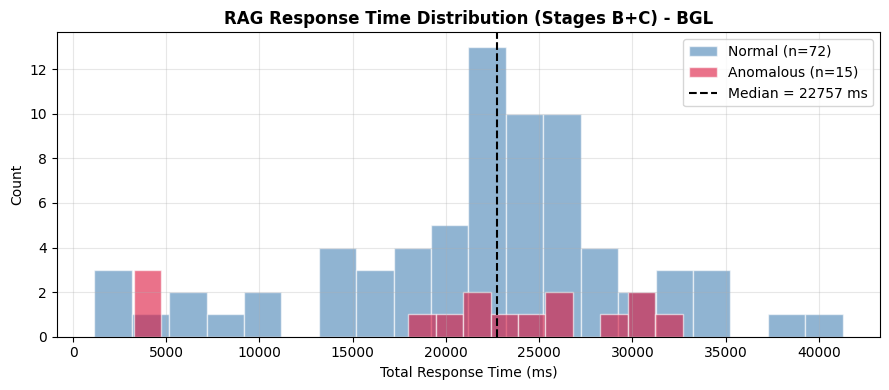

  Saved: bgl_svdd_self_ref_rag_response_time_dist.png


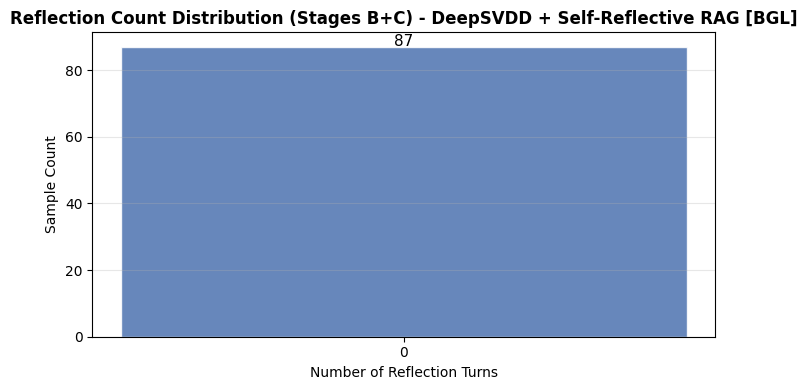

  Saved: bgl_svdd_self_ref_rag_reflection_dist.png

All visualisations complete.


In [3]:
# =============================================================================
# CELL 2 - IMPORTS, CONFIGURATION, DATA LOADING, SVDD TRAINING,
#           DENSE RETRIEVAL, SELF-REFLECTIVE INFERENCE, METRICS, VISUALISATION
# =============================================================================
# -- Standard library ---------------------------------------------------------
import json
import os
import re
import sys
import threading
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Any, Dict, List, Optional, Tuple

# -- Third-party --------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from groq import Groq
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
    precision_recall_curve,
)
from tqdm import tqdm

warnings.filterwarnings("ignore")

# -- Persistent KB (src/KnowledgeBase/) ---------------------------------------
_KB_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "KnowledgeBase"))
if _KB_DIR not in sys.path:
    sys.path.insert(0, _KB_DIR)
from kb_utils import KBClient

# -- Shared prompts (src/Prompts/) --------------------------------------------
_PROMPTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Prompts"))
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import (
    BGL_CONFIG,
    build_rag_system_prompt,
    format_retrieved_context,
)
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_faithfulness_prompt,
    build_answer_relevance_prompt,
    build_sre_appropriateness_prompt,
    build_devops_appropriateness_prompt,
    build_context_recall_prompt,
    build_root_cause_score_prompt,
    build_evidence_support_prompt,
    build_completeness_prompt_rag,
)

print(f"  Prompts dir : {_PROMPTS_DIR}")
RAG_SYSTEM_PROMPT = build_rag_system_prompt(BGL_CONFIG)

# =============================================================================
# SECTION 1 - CONFIGURATION
# =============================================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATASET = "BGL"

# -- Embedding and LLM models -------------------------------------------------
SVDD_EMBED_MODEL = "all-MiniLM-L6-v2"
LLM_MODEL        = "llama-3.1-8b-instant"
EVAL_MODEL       = "qwen/qwen3-32b"

# -- Deep SVDD hyper-parameters -----------------------------------------------
SVDD_HIDDEN_DIM           = 144
SVDD_REPR_DIM             = 64
SVDD_EPOCHS               = 100
SVDD_LR                   = 3e-5
SVDD_BATCH_SIZE           = 160
SVDD_WARMUP_EPOCHS        = 18
PSEUDO_ANOMALY_PERCENTILE = 94.5
FBETA                     = 0.4

# -- Dataset paths ------------------------------------------------------------
DATASET_CONFIG = {
    "structured_log_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_structured.csv"
    ),
    "templates_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_templates.csv"
    ),
    "label_col":     "Label",
    "normal_value":  "-",
    "event_id_col":  "EventId",
    "component_col": "Component",
    "level_col":     "Level",
    "content_col":   "Content",
    "template_col":  "EventTemplate",
}

# -- Split configuration ------------------------------------------------------
N_FEW_SHOT_NORMAL = 5
N_FEW_SHOT_ANOM   = 5
TEST_NORMAL_CAP   = 200
TEST_ANOMALY_CAP  = 15
SVDD_VAL_RATIO    = 0.25

# -- Routing bands ------------------------------------------------------------
NORMAL_CONFIDENCE_PERCENTILE = 70
UPPER_BAND_MARGIN_FACTOR     = 0.10

# -- Retrieval ----------------------------------------------------------------
RETRIEVAL_K           = 5
RETRIEVAL_K_KNOWLEDGE = 2
RETRIEVAL_K_ROLE      = 2

# -- Self-reflection ----------------------------------------------------------
MAX_REFLECTIONS                = 2
REFLECTION_CONFIDENCE_THRESHOLD = 0.75

# -- Groq API -----------------------------------------------------------------
MAX_RETRIES      = 3
RETRY_DELAY_S    = 5
REQUEST_DELAY_S  = 0.5
LLM_MAX_TOKENS   = 900
LLM_TEMPERATURE  = 0.0
EVAL_MAX_TOKENS  = 1024

EXPERIMENT_LABEL = "DeepSVDD + Self-Reflective RAG"
PREFIX           = "bgl_svdd_self_ref_rag"


def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.abspath(
        os.path.join(os.getcwd(), "..", "..", "Keys", f"groq_key_{n}.txt")
    )
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None


_ALL_PRIMARY  = [k for k in [_load_groq_key(i) for i in range(1, 6)] if k]
_ALL_FALLBACK = [k for k in [_load_groq_key(i) for i in range(6, 11)] if k]
if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt ... groq_key_5.txt"
    )

N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"  Dataset               : {DATASET}")
print(f"  SVDD embed model      : {SVDD_EMBED_MODEL}")
print(f"  LLM model             : {LLM_MODEL}")
print(f"  Eval model            : {EVAL_MODEL}")
print(f"  Device                : {device}")
print(f"  Test normal cap       : {TEST_NORMAL_CAP}")
print(f"  Test anomaly cap      : {TEST_ANOMALY_CAP}")
print(f"  Retrieval K (logs)    : {RETRIEVAL_K}")
print(f"  Retrieval K (knowl.)  : {RETRIEVAL_K_KNOWLEDGE} / collection")
print(f"  Retrieval K (roles)   : {RETRIEVAL_K_ROLE} / collection")
print(f"  Max reflections       : {MAX_REFLECTIONS}")
print(f"  Reflection conf. thr. : {REFLECTION_CONFIDENCE_THRESHOLD}")
print(
    f"  Normal confidence pct : "
    f"{NORMAL_CONFIDENCE_PERCENTILE}th percentile of val distances"
)
print(
    f"  Upper band margin     : "
    f"+{UPPER_BAND_MARGIN_FACTOR * 100:.0f}% of threshold"
)
print(
    f"  Primary Groq keys     : {len(_ALL_PRIMARY)}"
    f"  | Fallback: {len(_ALL_FALLBACK)}"
)

# =============================================================================
# SECTION 2 - DATA LOADING
# =============================================================================


def build_log_text(row: pd.Series) -> str:
    comp = str(row.get("Component",     "")).strip()
    lvl  = str(row.get("Level",         "")).strip()
    cont = str(row.get("Content",       "")).strip()
    tmpl = str(row.get("EventTemplate", "")).strip()
    return f"[{comp}] [{lvl}] {cont} | Template: {tmpl}"


def load_bgl(config: Dict) -> pd.DataFrame:
    print("\nLoading BGL structured log ...")
    df_logs = pd.read_csv(config["structured_log_path"])
    df_tmpl = pd.read_csv(config["templates_path"])
    df = df_logs.merge(
        df_tmpl, on=config["event_id_col"],
        how="left", suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(build_log_text, axis=1)
    n_norm = int(df["is_normal"].sum())
    n_anom = int((~df["is_normal"]).sum())
    print(f"  Rows: {len(df)},  Normal: {n_norm},  Anomalous: {n_anom}")
    return df


df = load_bgl(DATASET_CONFIG)

# =============================================================================
# SECTION 3 - UNIFIED DATA SPLIT
#
# test_df  - identical split to E06/E03 (same 200 normals + 15 anomalies)
#            for fair cross-experiment comparison.
# val_df   - SVDD_VAL_RATIO of remaining normals for threshold calibration.
# train_df - all remaining normals; no anomalies (one-class SVDD training).
# =============================================================================


def create_e10_splits(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anom: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    svdd_val_ratio: float,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df_n = (
        df[df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    df_a = (
        df[~df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    test_normals = df_n.iloc[
        n_few_shot_normal:n_few_shot_normal + test_normal_cap
    ].reset_index(drop=True)
    test_anom = df_a.iloc[
        n_few_shot_anom:n_few_shot_anom + test_anomaly_cap
    ].reset_index(drop=True)
    test_df = (
        pd.concat([test_normals, test_anom], ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    svdd_pool = df_n.iloc[
        n_few_shot_normal + test_normal_cap:
    ].reset_index(drop=True)
    n_val    = int(len(svdd_pool) * svdd_val_ratio)
    val_df   = svdd_pool.iloc[:n_val].reset_index(drop=True)
    train_df = svdd_pool.iloc[n_val:].reset_index(drop=True)
    return train_df, val_df, test_df


print("\nCreating splits ...")
train_df, val_df, test_df = create_e10_splits(
    df,
    N_FEW_SHOT_NORMAL, N_FEW_SHOT_ANOM,
    TEST_NORMAL_CAP,   TEST_ANOMALY_CAP,
    SVDD_VAL_RATIO,    RANDOM_SEED,
)

n_tn = int(test_df["is_normal"].sum())
n_ta = int((~test_df["is_normal"]).sum())
print(f"  SVDD train  : {len(train_df):>6}  normals")
print(f"  SVDD val    : {len(val_df):>6}  normals  (threshold calibration)")
print(f"  Test Normal : {n_tn:>6}  ({n_tn / len(test_df) * 100:.1f}%)")
print(f"  Test Anomal : {n_ta:>6}  ({n_ta / len(test_df) * 100:.1f}%)")
print(f"  Test Total  : {len(test_df):>6}")

# =============================================================================
# SECTION 4 - SENTENCE EMBEDDINGS (for SVDD)
# =============================================================================

print(f"\nLoading SVDD embedding model '{SVDD_EMBED_MODEL}' ...")
svdd_embedder = SentenceTransformer(SVDD_EMBED_MODEL)
SVDD_EMBED_DIM = svdd_embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {SVDD_EMBED_DIM}")

print(f"\nEncoding SVDD train set ({len(train_df)} samples) ...")
train_embeddings = svdd_embedder.encode(
    train_df["log_text"].tolist(), batch_size=64, show_progress_bar=True,
)
print(f"Encoding SVDD val set ({len(val_df)} samples) ...")
val_embeddings = svdd_embedder.encode(
    val_df["log_text"].tolist(), batch_size=64, show_progress_bar=True,
)
print(f"Encoding test set ({len(test_df)} samples) ...")
test_embeddings = svdd_embedder.encode(
    test_df["log_text"].tolist(), batch_size=64, show_progress_bar=True,
)
print(
    f"  Train: {train_embeddings.shape}  "
    f"Val: {val_embeddings.shape}  "
    f"Test: {test_embeddings.shape}"
)

# =============================================================================
# SECTION 5 - DEEP SVDD MODEL DEFINITION AND TRAINING
# =============================================================================


class DeepSVDDNetwork(nn.Module):
    """Feed-forward encoder: input_dim -> hidden -> repr_dim (L2-normalised)."""

    def __init__(self, input_dim: int, hidden_dim: int, repr_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, repr_dim, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return nn.functional.normalize(self.network(x), p=2, dim=1)


def compute_svdd_centre_warmstart(
    model, data_tensor, n_warmup_epochs, lr, batch_size
):
    print(f"  Running {n_warmup_epochs} warm-up epochs ...")
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(data_tensor),
        batch_size=batch_size, shuffle=True,
    )
    model.train()
    for _ in range(n_warmup_epochs):
        for (batch,) in loader:
            opt.zero_grad()
            (-model(batch).var(dim=0).sum()).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        centre = model(data_tensor).mean(dim=0)
    print(f"  Centre norm after warmup : {centre.norm().item():.4f}")
    return centre


def train_deep_svdd(model, centre, train_tensor, n_epochs, lr, batch_size):
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_tensor),
        batch_size=batch_size, shuffle=True,
    )
    losses = []
    model.train()
    for epoch in range(1, n_epochs + 1):
        bl = []
        for (batch,) in loader:
            opt.zero_grad()
            torch.sum((model(batch) - centre) ** 2, dim=1).mean().backward()
            opt.step()
            bl.append(
                torch.sum(
                    (model(batch.detach()) - centre) ** 2, dim=1
                ).mean().item()
            )
        losses.append(float(np.mean(bl)))
        if epoch % 10 == 0 or epoch in (1, n_epochs):
            print(f"  Epoch {epoch:3d}/{n_epochs}  Loss: {losses[-1]:.6f}")
    return losses


def compute_svdd_distances(model, centre, embeddings, device):
    model.eval()
    with torch.no_grad():
        emb_t = torch.tensor(embeddings, dtype=torch.float32).to(device)
        reps  = model(emb_t)
        dists = torch.sum((reps - centre) ** 2, dim=1)
    return dists.cpu().numpy()


svdd_model = DeepSVDDNetwork(
    SVDD_EMBED_DIM, SVDD_HIDDEN_DIM, SVDD_REPR_DIM
).to(device)
print(
    f"\nDeep SVDD: {SVDD_EMBED_DIM} -> {SVDD_HIDDEN_DIM} -> "
    f"{SVDD_HIDDEN_DIM} -> {SVDD_REPR_DIM} (L2-norm)"
)
print(f"Parameters: {sum(p.numel() for p in svdd_model.parameters()):,}")

train_tensor = torch.tensor(train_embeddings, dtype=torch.float32).to(device)

print("\nComputing warm-start hypersphere centre ...")
svdd_centre = compute_svdd_centre_warmstart(
    svdd_model, train_tensor, SVDD_WARMUP_EPOCHS, SVDD_LR, SVDD_BATCH_SIZE,
)
print(f"\nTraining Deep SVDD for {SVDD_EPOCHS} epochs ...")
epoch_losses = train_deep_svdd(
    svdd_model, svdd_centre, train_tensor, SVDD_EPOCHS, SVDD_LR,
    SVDD_BATCH_SIZE,
)
print(f"\nTraining complete.  Final loss: {epoch_losses[-1]:.6f}")

# =============================================================================
# SECTION 6 - THRESHOLD CALIBRATION (VALIDATION SET)
# =============================================================================

print("\nCalibrating anomaly threshold on validation set ...")
val_distances = compute_svdd_distances(
    svdd_model, svdd_centre, val_embeddings, device,
)
print(
    f"  Val dist  min={val_distances.min():.4f}  "
    f"median={np.median(val_distances):.4f}  "
    f"max={val_distances.max():.4f}"
)

pseudo_labels = (
    val_distances >= np.percentile(val_distances, PSEUDO_ANOMALY_PERCENTILE)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_distances,
)
beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx       = int(np.argmax(fbeta_scores))
svdd_threshold = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

lower_band = float(np.percentile(val_distances, NORMAL_CONFIDENCE_PERCENTILE))
upper_band = svdd_threshold * (1.0 + UPPER_BAND_MARGIN_FACTOR)

print(f"\n  SVDD threshold                : {svdd_threshold:.4f}")
print(
    f"  Lower band (P{NORMAL_CONFIDENCE_PERCENTILE} of val dists)"
    f" : {lower_band:.4f}"
)
print(
    f"  Upper band (+{UPPER_BAND_MARGIN_FACTOR * 100:.0f}% of threshold)"
    f" : {upper_band:.4f}"
)
print(f"  Routing bands:")
print(f"    Clearly Normal    : distance < {lower_band:.4f}")
print(
    f"    Uncertain         : {lower_band:.4f}"
    f" <= distance <= {upper_band:.4f}"
)
print(f"    Clearly Anomalous : distance > {upper_band:.4f}")

# =============================================================================
# SECTION 7 - SVDD TEST SCORING AND ROUTING
# =============================================================================

_svdd_t0 = time.perf_counter()
test_distances = compute_svdd_distances(
    svdd_model, svdd_centre, test_embeddings, device,
)
svdd_inference_ms = (time.perf_counter() - _svdd_t0) * 1000.0


def get_route(distance: float) -> str:
    if distance < lower_band:
        return "clearly_normal"
    if distance > upper_band:
        return "clearly_anomalous"
    return "uncertain"


def svdd_label_confidence(distance: float, is_anomalous_pred: bool) -> float:
    denom = 2.0 * svdd_threshold if svdd_threshold > 0 else 1.0
    norm  = max(0.0, min(1.0, distance / denom))
    raw   = norm if is_anomalous_pred else (1.0 - norm)
    return round(max(0.50, min(0.99, raw)), 4)


routes, svdd_preds, svdd_confs = [], [], []
for d in test_distances:
    is_anom = bool(d > svdd_threshold)
    routes.append(get_route(float(d)))
    svdd_preds.append(1 if is_anom else 0)
    svdd_confs.append(svdd_label_confidence(float(d), is_anom))

route_counts = {
    r: routes.count(r)
    for r in ["clearly_normal", "uncertain", "clearly_anomalous"]
}
print(
    f"\nRouting summary  (n={len(test_df)})  -  "
    f"SVDD inference: {svdd_inference_ms:.1f} ms"
)
for r, c in route_counts.items():
    print(f"  {r:<22} : {c:>4}  ({c / len(test_df) * 100:.1f}%)")

# =============================================================================
# SECTION 8 - PERSISTENT KNOWLEDGE BASE
# =============================================================================

print("\nConnecting to persistent Qdrant KB ...")
kb = KBClient()
kb.collection_stats()
print("  KB client ready")


def _fmt_knowledge(hits: List[Dict]) -> str:
    if not hits:
        return "(none)"
    lines = []
    for h in hits:
        cat = h.get("category", "").upper()
        sec = h.get("section", "")
        tag = f" | {sec}" if sec else ""
        lines.append(
            f"[{cat}{tag} | score={h['score']:.3f}]\n{h['text'][:400]}"
        )
    return "\n\n".join(lines)


# =============================================================================
# SECTION 9 - RETRIEVAL HELPERS
#
# retrieve() uses standard dense retrieval from the persistent KB (E03/E06
# pattern).  _build_rag_user_prompt() prepends the SVDD routing signal so
# the LLM is aware of where the log sits relative to the decision boundary.
# =============================================================================


def _label_vote_summary(log_hits: List[Dict]) -> str:
    if not log_hits:
        return ""
    n_total  = len(log_hits)
    n_anom   = sum(1 for h in log_hits if h["binary_label"] == 1)
    n_normal = n_total - n_anom
    if n_anom > n_normal:
        majority = "Anomalous"
    elif n_normal > n_anom:
        majority = "Normal"
    else:
        majority = "tie"
    total_score = sum(h["score"] for h in log_hits) or 1.0
    w_anom      = sum(h["score"] for h in log_hits if h["binary_label"] == 1)
    w_anom      = w_anom / total_score * 100.0
    w_normal    = 100.0 - w_anom
    return (
        f"[Label vote: {n_normal} Normal, {n_anom} Anomalous "
        f"out of {n_total} retrieved - majority: {majority} | "
        f"weighted by similarity: Normal {w_normal:.1f}%, "
        f"Anomalous {w_anom:.1f}%]"
    )


def _build_rag_user_prompt(
    log_text: str,
    log_hits: List[Dict],
    system_hits: List[Dict],
    role_hits: List[Dict],
    svdd_route: str,
    svdd_distance: float,
) -> str:
    log_ctx      = format_retrieved_context(log_hits) if log_hits else "(none)"
    vote_summary = _label_vote_summary(log_hits)
    vote_line    = f"{vote_summary}\n" if vote_summary else ""
    system_ctx   = _fmt_knowledge(system_hits)
    role_ctx     = _fmt_knowledge(role_hits)

    if svdd_route == "uncertain":
        svdd_note = (
            f"[SVDD Signal] Distance to normal hypersphere: {svdd_distance:.4f}  "
            f"(threshold: {svdd_threshold:.4f}) - log is NEAR the decision boundary. "
            "Classification is uncertain. Use the retrieved context to determine "
            "whether this log is Normal or Anomalous.\n"
        )
    else:
        svdd_note = (
            f"[SVDD Signal] Distance to normal hypersphere: {svdd_distance:.4f}  "
            f"(threshold: {svdd_threshold:.4f}) - log is CLEARLY ANOMALOUS "
            f"(exceeds threshold by {svdd_distance - svdd_threshold:.4f}). "
            "Label this log as Anomalous and focus your analysis on root cause "
            "and remediation.\n"
        )
    return (
        f"{svdd_note}\n"
        f"Log entry to analyze:\n{log_text}\n\n"
        f"[A] Similar log examples from knowledge base:\n{vote_line}{log_ctx}\n\n"
        f"[B] System knowledge context "
        f"(architecture, severity taxonomy, RCA examples):\n{system_ctx}\n\n"
        f"[C] Role scope reference - use to understand each role's "
        f"responsibilities; do not copy verbatim - derive specific "
        f"actions from the log evidence above:\n{role_ctx}"
    )


def retrieve(
    query_text: str,
) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """Standard dense retrieval from the persistent KB (E03/E06 pattern)."""
    raw_logs = kb.query_bgl_logs(query_text, top_k=RETRIEVAL_K)
    log_hits = [
        {
            "log_text":     h["text"],
            "label":        h["label"],
            "binary_label": 0 if h["label"] == "Normal" else 1,
            "score":        h["score"],
            "rank":         idx + 1,
        }
        for idx, h in enumerate(raw_logs)
    ]

    raw_system = kb.query_multi(
        ["bgl_architecture", "bgl_severity", "bgl_rca"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_KNOWLEDGE,
    )
    system_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", "") or h.get("rca_section", ""),
            "score":    h["score"],
        }
        for h in raw_system
    ]

    raw_roles = kb.query_multi(
        ["role_sre", "role_devops"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_ROLE,
    )
    role_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", ""),
            "score":    h["score"],
        }
        for h in raw_roles
    ]
    return log_hits, system_hits, role_hits


print(f"\nRetrieval sanity check ...")
_q = test_df.iloc[0]["log_text"]
print(f"  Query: {_q[:90]}")
_lh, _sh, _rh = retrieve(_q)
print(f"  Log hits ({len(_lh)}) [Dense]:")
for _r in _lh:
    print(
        f"    [{_r['rank']}] {_r['label']:9s}"
        f" score={_r['score']:.4f}  {_r['log_text'][:60]}"
    )
print(f"  System hits: {len(_sh)}  Role hits: {len(_rh)}")

# =============================================================================
# SECTION 10 - GROQ CLIENT AND API HELPERS
# =============================================================================

_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)
_worker_key    = threading.local()
_assign_lock   = threading.Lock()
_assign_idx    = [0]


def _init_worker_key() -> None:
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx     = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return "ratelimit" in s.lower() or "rate_limit" in s.lower() or "429" in s


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
) -> Tuple[Optional[str], float, float]:
    _init_worker_key()
    budget = MAX_RETRIES + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client = Groq(api_key=_worker_key.current)
            t0     = time.perf_counter()
            resp   = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t1    = time.perf_counter()
            total = (t1 - t0) * 1000.0
            usage = resp.usage
            c_tok = usage.completion_tokens if usage else 1
            p_tok = usage.prompt_tokens if usage else 0
            gen   = total * (c_tok / ((p_tok + c_tok) or 1))
            return resp.choices[0].message.content.strip(), total - gen, gen
        except Exception as e:
            if _is_rate_limit(e):
                if _rotate_to_fallback():
                    print(
                        f"  [rate-limit] Rotated to fallback "
                        f"(attempt {attempt + 1})",
                        flush=True,
                    )
                    continue
                print(
                    "  [rate-limit] All keys exhausted - sleeping 60s",
                    flush=True,
                )
                time.sleep(60)
            else:
                time.sleep(RETRY_DELAY_S * min(attempt + 1, 5))
    return None, 0.0, 0.0


def _strip_thinking(raw: str) -> str:
    stripped = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    return stripped if stripped else raw


print(f"  Workers     : {N_PARALLEL_WORKERS}")
print(f"  Primary keys: {len(_ALL_PRIMARY)}  | Fallback: {len(_ALL_FALLBACK)}")

# =============================================================================
# SECTION 11 - RESPONSE PARSER
# =============================================================================


def _compute_risk(si: Any, et: Any, cp: Any) -> Dict:
    si  = max(1, min(4, int(si)))
    et  = max(1, min(4, int(et)))
    cp  = max(1, min(4, int(cp)))
    tot = round(si * 0.4 + et * 0.3 + cp * 0.2, 3)
    lvl = "High" if tot >= 2.8 else ("Medium" if tot >= 1.8 else "Low")
    return {
        "system_impact": si, "error_type": et, "cascade_potential": cp,
        "total_score": tot, "risk_level": lvl,
    }


def parse_rag_response(raw: Optional[str]) -> Dict:
    default = {
        "label": "Normal", "confidence": 0.5, "anomaly_explanation": "",
        "rca_summary": "", "rca_detailed": "", "rca_confidence_level": "",
        "rca_confidence_reasoning": "", "rca_causal_chain": [],
        "rca_supporting_evidence": [],
        "risk_system_impact": 0, "risk_error_type": 0,
        "risk_cascade_potential": 0,
        "risk_total_score": 0.0, "risk_level": "",
        "sre_action": "", "devops_action": "", "parse_error": True,
    }
    if raw is None:
        return default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        m = re.search(r"\{.*\}", cleaned, re.DOTALL)
        if m:
            p = json.loads(m.group())
            r = default.copy()
            r["parse_error"] = False
            r["label"]       = str(p.get("label", "Normal"))
            r["confidence"]  = float(
                max(0.0, min(1.0, float(p.get("confidence", 0.5))))
            )
            if r["label"] == "Anomalous":
                r["anomaly_explanation"]      = str(p.get("anomaly_explanation", ""))
                rca = p.get("rca", {})
                r["rca_summary"]              = str(rca.get("summary", ""))
                r["rca_detailed"]             = str(rca.get("detailed_description", ""))
                r["rca_confidence_level"]     = str(rca.get("confidence_level", ""))
                r["rca_confidence_reasoning"] = str(rca.get("confidence_reasoning", ""))
                r["rca_causal_chain"]         = list(rca.get("causal_chain", []))
                r["rca_supporting_evidence"]  = list(rca.get("supporting_evidence", []))
                rs  = p.get("risk_score", {})
                crs = _compute_risk(
                    rs.get("system_impact", 2),
                    rs.get("error_type", 2),
                    rs.get("cascade_potential", 2),
                )
                r["risk_system_impact"]     = crs["system_impact"]
                r["risk_error_type"]        = crs["error_type"]
                r["risk_cascade_potential"] = crs["cascade_potential"]
                r["risk_total_score"]       = crs["total_score"]
                r["risk_level"]             = crs["risk_level"]
                rem = p.get("remediation", {})
                r["sre_action"]    = str(rem.get("sre_action", ""))
                r["devops_action"] = str(rem.get("devops_action", ""))
            return r
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return default.copy()


# =============================================================================
# SECTION 12 - SELF-REFLECTIVE INFERENCE PIPELINE
#
# Stage A  clearly_normal    - SVDD-only; no LLM call; instant label = Normal
# Stage B  uncertain         - Self-Reflective RAG classifies; label may differ
# Stage C  clearly_anomalous - Label forced Anomalous; Self-Reflective RAG RCA
#
# Self-reflection: after initial inference, if confidence < threshold or parse
# fails, the model receives its own response as input for targeted self-critique
# (up to MAX_REFLECTIONS turns).  Tracked: n_reflections, initial_label,
# label_changed.
# =============================================================================

print(f"\nStarting {EXPERIMENT_LABEL} inference ...")
print(
    f"  Stage A (clearly_normal)    : "
    f"{route_counts['clearly_normal']} samples - no LLM call"
)
print(
    f"  Stage B (uncertain)         : "
    f"{route_counts['uncertain']} samples - Self-Reflective RAG classifies"
)
print(
    f"  Stage C (clearly_anomalous) : "
    f"{route_counts['clearly_anomalous']} samples - Self-Reflective RAG RCA"
)
print(
    f"  MAX_REFLECTIONS                : {MAX_REFLECTIONS}"
)
print(
    f"  REFLECTION_CONFIDENCE_THRESHOLD: {REFLECTION_CONFIDENCE_THRESHOLD}"
)


def _build_reflection_prompt(
    log_text: str,
    user_prompt: str,
    initial_response: str,
) -> str:
    return (
        f"You previously analysed this log entry:\n{log_text}\n\n"
        f"Retrieved context and SVDD signal used:\n{user_prompt}\n\n"
        f"Your initial response was:\n{initial_response}\n\n"
        "Please critique your response carefully:\n"
        "  1. Did you overlook any evidence in the log or retrieved context?\n"
        "  2. Is the label and confidence level fully justified given the "
        "SVDD signal?\n"
        "  3. Is the RCA specific to this log or too generic?\n\n"
        "Provide a revised, improved response. "
        "Output ONLY valid JSON."
    )


_SVDD_ONLY      = []
_RAG_CANDIDATES = []

for i, (route, dist, conf) in enumerate(
    zip(routes, test_distances, svdd_confs)
):
    row_dict = test_df.iloc[i].to_dict()
    row_dict.update({
        "idx": i, "svdd_distance": float(dist),
        "svdd_route": route, "svdd_conf": conf,
        "svdd_pred_label": svdd_preds[i],
    })
    if route == "clearly_normal":
        _SVDD_ONLY.append(row_dict)
    else:
        _RAG_CANDIDATES.append(row_dict)


def _run_rag_inference(row_dict: dict) -> dict:
    """Execute Stage B or C: retrieve (dense) -> LLM -> self-reflect -> parse."""
    t_ret0 = time.perf_counter()
    log_hits, system_hits, role_hits = retrieve(row_dict["log_text"])
    ret_ms = (time.perf_counter() - t_ret0) * 1000.0

    user_prompt = _build_rag_user_prompt(
        row_dict["log_text"], log_hits, system_hits, role_hits,
        row_dict["svdd_route"], row_dict["svdd_distance"],
    )
    raw, l_ms, g_ms = call_groq(RAG_SYSTEM_PROMPT, user_prompt, LLM_MODEL)
    parsed = parse_rag_response(raw)

    if row_dict["svdd_route"] == "clearly_anomalous":
        parsed["label"] = "Anomalous"

    initial_label = parsed["label"]
    n_reflections = 0
    conf          = parsed.get("confidence", 0.5)

    while (
        n_reflections < MAX_REFLECTIONS
        and (conf < REFLECTION_CONFIDENCE_THRESHOLD
             or parsed.get("parse_error", False))
    ):
        ref_prompt = _build_reflection_prompt(
            row_dict["log_text"],
            user_prompt,
            raw or "(no response)",
        )
        raw_r, l_r, g_r = call_groq(
            RAG_SYSTEM_PROMPT, ref_prompt, LLM_MODEL
        )
        l_ms += l_r
        g_ms += g_r
        if raw_r:
            parsed_r = parse_rag_response(raw_r)
            if not parsed_r.get("parse_error", True):
                raw    = raw_r
                parsed = parsed_r
                if row_dict["svdd_route"] == "clearly_anomalous":
                    parsed["label"] = "Anomalous"
                conf = parsed.get("confidence", 0.5)
        n_reflections += 1

    parsed.update({
        "true_label":      int(row_dict["binary_label"]),
        "log_text":        row_dict["log_text"],
        "raw_response":    raw,
        "svdd_distance":   row_dict["svdd_distance"],
        "svdd_route":      row_dict["svdd_route"],
        "svdd_pred_label": row_dict["svdd_pred_label"],
        "retrieved_docs":  log_hits,
        "knowledge_docs":  system_hits + role_hits,
        "retrieval_ms":    ret_ms,
        "latency_ms":      l_ms,
        "generation_ms":   g_ms,
        "idx":             row_dict["idx"],
        "n_reflections":   n_reflections,
        "initial_label":   initial_label,
        "label_changed":   (initial_label != parsed["label"]),
    })
    return parsed


_STAGE_A_DEFAULTS = {
    "anomaly_explanation": "", "rca_summary": "", "rca_detailed": "",
    "rca_confidence_level": "", "rca_confidence_reasoning": "",
    "rca_causal_chain": [], "rca_supporting_evidence": [],
    "risk_system_impact": 0, "risk_error_type": 0,
    "risk_cascade_potential": 0,
    "risk_total_score": 0.0, "risk_level": "",
    "sre_action": "", "devops_action": "",
    "parse_error": False, "raw_response": None,
    "retrieved_docs": [], "knowledge_docs": [],
    "retrieval_ms": 0.0, "latency_ms": 0.0, "generation_ms": 0.0,
    "n_reflections": 0, "initial_label": "Normal", "label_changed": False,
}
stage_a_results = []
for row_dict in _SVDD_ONLY:
    entry = {
        **_STAGE_A_DEFAULTS,
        "true_label":      int(row_dict["binary_label"]),
        "log_text":        row_dict["log_text"],
        "label":           "Normal",
        "confidence":      row_dict["svdd_conf"],
        "svdd_distance":   row_dict["svdd_distance"],
        "svdd_route":      "clearly_normal",
        "svdd_pred_label": row_dict["svdd_pred_label"],
        "idx":             row_dict["idx"],
    }
    stage_a_results.append(entry)

stage_bc_results = [None] * len(_RAG_CANDIDATES)
with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
    future_to_ci = {
        executor.submit(_run_rag_inference, row): ci
        for ci, row in enumerate(_RAG_CANDIDATES)
    }
    for future in tqdm(
        as_completed(future_to_ci),
        total=len(_RAG_CANDIDATES),
        desc="Self-Reflective RAG (B+C)",
    ):
        ci = future_to_ci[future]
        try:
            stage_bc_results[ci] = future.result()
        except Exception as exc:
            rd = _RAG_CANDIDATES[ci]
            print(f"  Worker error on idx {rd['idx']}: {exc}")
            fallback_label = (
                "Anomalous"
                if rd["svdd_route"] == "clearly_anomalous"
                else "Normal"
            )
            stage_bc_results[ci] = {
                **_STAGE_A_DEFAULTS,
                "true_label":      int(rd["binary_label"]),
                "log_text":        rd["log_text"],
                "label":           fallback_label,
                "confidence":      rd["svdd_conf"],
                "svdd_distance":   rd["svdd_distance"],
                "svdd_route":      rd["svdd_route"],
                "svdd_pred_label": rd["svdd_pred_label"],
                "parse_error": True,
                "idx": rd["idx"],
            }

# =============================================================================
# SECTION 13 - MERGE AND SORT RESULTS
# =============================================================================

all_results = sorted(
    stage_a_results + stage_bc_results, key=lambda r: r["idx"]
)
results_df = pd.DataFrame(all_results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)

rag_mask   = results_df["svdd_route"].isin(
    ["uncertain", "clearly_anomalous"]
).values
parse_errs  = int(results_df.loc[rag_mask, "parse_error"].sum())
n_reflected = int((results_df.loc[rag_mask, "n_reflections"] > 0).sum())
n_changed   = int(results_df.loc[rag_mask, "label_changed"].sum())

print(f"\n  Total samples        : {len(results_df)}")
print(f"  Stage A (no LLM)     : {len(stage_a_results)}")
print(f"  Stages B+C (LLM)     : {int(rag_mask.sum())}")
print(f"  Parse errors (B+C)   : {parse_errs} / {int(rag_mask.sum())}")
print(f"  Triggered reflection  : {n_reflected} / {int(rag_mask.sum())}")
print(f"  Label changed by refl.: {n_changed}")

# =============================================================================
# SECTION 14 - EFFICIENCY SUMMARY
# =============================================================================

ret_arr = results_df["retrieval_ms"].values
lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values

ret_rag = ret_arr[rag_mask]
lat_rag = lat_arr[rag_mask]
gen_rag = gen_arr[rag_mask]
tot_rag = ret_rag + lat_rag + gen_rag

print("\n" + "=" * 90)
print(
    f"  EFFICIENCY  [{DATASET}]  {EXPERIMENT_LABEL}  "
    f"(n={len(results_df)}, RAG calls={int(rag_mask.sum())})"
)
print("=" * 90)
print(
    f"  {'Metric':<22}  {'Retrieval (ms)':>15}  "
    f"{'Prefill (ms)':>14}  {'Gen (ms)':>10}  {'Total (ms)':>12}"
)
print("-" * 90)


def _pct95(x):
    return np.percentile(x, 95)


def _pct99(x):
    return np.percentile(x, 99)


_stat_fns = {
    "Mean":   np.mean,
    "Median": np.median,
    "p95":    _pct95,
    "p99":    _pct99,
    "Min":    np.min,
    "Max":    np.max,
}
for lbl, fn in _stat_fns.items():
    if len(ret_rag):
        print(
            f"  RAG (B+C) {lbl:<12}  {fn(ret_rag):>15.1f}  "
            f"{fn(lat_rag):>14.1f}  {fn(gen_rag):>10.1f}  "
            f"{fn(tot_rag):>12.1f}"
        )
print(
    f"  SVDD batch inference (n={len(results_df)}) : "
    f"{svdd_inference_ms:.1f} ms"
)
print(
    f"  SVDD per-sample avg              : "
    f"{svdd_inference_ms / len(results_df):.2f} ms"
)
print("=" * 90)

latency_summary = {
    "mean_retrieval_ms":  float(np.mean(ret_rag)) if len(ret_rag) else 0.0,
    "p95_retrieval_ms":   float(np.percentile(ret_rag, 95)) if len(ret_rag) else 0.0,
    "mean_latency_ms":    float(np.mean(lat_rag)) if len(lat_rag) else 0.0,
    "p95_latency_ms":     float(np.percentile(lat_rag, 95)) if len(lat_rag) else 0.0,
    "mean_generation_ms": float(np.mean(gen_rag)) if len(gen_rag) else 0.0,
    "p95_generation_ms":  float(np.percentile(gen_rag, 95)) if len(gen_rag) else 0.0,
    "mean_total_ms":      float(np.mean(tot_rag)) if len(tot_rag) else 0.0,
    "p95_total_ms":       float(np.percentile(tot_rag, 95)) if len(tot_rag) else 0.0,
    "svdd_batch_ms":      svdd_inference_ms,
    "rag_call_count":     int(rag_mask.sum()),
}

# =============================================================================
# SECTION 15 - STANDARD ANOMALY DETECTION METRICS
# =============================================================================

y_true   = results_df["true_label"].tolist()
y_scores = test_distances.tolist()

svdd_only_pred = svdd_preds
svdd_acc  = accuracy_score(y_true, svdd_only_pred)
svdd_prec = precision_score(y_true, svdd_only_pred, pos_label=1, zero_division=0)
svdd_rec  = recall_score(y_true, svdd_only_pred, pos_label=1, zero_division=0)
svdd_f1   = f1_score(y_true, svdd_only_pred, pos_label=1, zero_division=0)
svdd_cm   = confusion_matrix(y_true, svdd_only_pred)
svdd_tn, svdd_fp, svdd_fn, svdd_tp = svdd_cm.ravel()
svdd_fpr  = svdd_fp / (svdd_fp + svdd_tn) if (svdd_fp + svdd_tn) > 0 else 0.0
svdd_fnr  = svdd_fn / (svdd_fn + svdd_tp) if (svdd_fn + svdd_tp) > 0 else 0.0
try:
    svdd_auc = roc_auc_score(y_true, y_scores)
except ValueError:
    svdd_auc = float("nan")

n_pos, n_neg = y_true.count(1), y_true.count(0)
print("\n" + "=" * 64)
print(f"  STAGE 1 - Deep SVDD Standalone  [{DATASET}]")
print("=" * 64)
print(f"  Test set  : {len(y_true)}  (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={svdd_tp}  TN={svdd_tn}  FP={svdd_fp}  FN={svdd_fn}")
print("-" * 64)
print(f"  Accuracy   : {svdd_acc:.4f}  ({svdd_acc * 100:.2f}%)")
print(f"  Precision  : {svdd_prec:.4f}")
print(f"  Recall     : {svdd_rec:.4f}")
print(f"  F1-Score   : {svdd_f1:.4f}")
print(f"  FPR        : {svdd_fpr:.4f}")
print(f"  FNR        : {svdd_fnr:.4f}")
print(f"  AUC-ROC    : {svdd_auc:.4f}")
print("=" * 64)

y_pred = results_df["pred_label"].tolist()

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val  = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc      = svdd_auc
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

print(f"\n  STAGE 2 - {EXPERIMENT_LABEL}  [{DATASET}]")
print("=" * 64)
print(f"  Test set  : {len(y_true)}  (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("-" * 64)
print(f"  Accuracy   : {acc:.4f}  ({acc * 100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  FPR        : {fpr_val:.4f}")
print(f"  FNR        : {fnr_val:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print("=" * 64)

print(f"\n  DELTA  (Self-Reflective RAG - SVDD standalone)  [{DATASET}]")
print("=" * 64)
print(f"  {'Metric':<12}  {'SVDD':>8}  {'RAG':>8}  {'Delta':>9}  {'':>2}")
print("-" * 64)
for name, s_val, h_val in [
    ("Accuracy",  svdd_acc,  acc),
    ("Precision", svdd_prec, prec),
    ("Recall",    svdd_rec,  rec),
    ("F1-Score",  svdd_f1,   f1),
    ("FPR",       svdd_fpr,  fpr_val),
    ("FNR",       svdd_fnr,  fnr_val),
    ("AUC-ROC",   svdd_auc,  auc),
]:
    d     = h_val - s_val
    arrow = "+" if d > 1e-4 else ("-" if d < -1e-4 else "=")
    print(f"  {name:<12}  {s_val:>8.4f}  {h_val:>8.4f}  {d:>+9.4f}  {arrow}")
print("=" * 64)
print(
    f"  RAG processed : {int(rag_mask.sum())} / {len(results_df)} samples  "
    f"({int(rag_mask.sum()) / len(results_df) * 100:.1f}% of test set)"
)
print(f"  Clearly normal (skipped)       : {route_counts['clearly_normal']}")
print(f"  Uncertain (RAG reclassified)   : {route_counts['uncertain']}")
print(f"  Clearly anomalous (RAG RCA)    : {route_counts['clearly_anomalous']}")
print(f"  Triggered reflection           : {n_reflected}")
print(f"  Label changed by reflection    : {n_changed}")

std_metrics = dict(
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    fpr=fpr_val, fnr=fnr_val, auc_roc=auc,
    fpr_curve=fpr_curve, tpr_curve=tpr_curve,
    svdd_accuracy=svdd_acc, svdd_precision=svdd_prec,
    svdd_recall=svdd_rec, svdd_f1=svdd_f1,
    svdd_fpr=svdd_fpr, svdd_fnr=svdd_fnr, svdd_auc=svdd_auc,
)

# =============================================================================
# SECTION 16 - RAG EVALUATION METRICS (TRUE ANOMALIES ONLY)
# =============================================================================


def score_with_judge(prompt: str) -> Tuple[float, str]:
    raw, _, _ = call_groq(
        JUDGE_SYSTEM_PROMPT, prompt, EVAL_MODEL,
        max_tokens=EVAL_MAX_TOKENS, temperature=0.0,
    )
    if raw is None:
        return 0.0, "API error"
    content = _strip_thinking(raw)
    try:
        c = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        m = re.search(r"\{.*\}", c, re.DOTALL)
        if m:
            p = json.loads(m.group())
            return (
                max(0.0, min(1.0, float(p.get("score", 0.0)))),
                str(p.get("reason", "")),
            )
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r"\b0\.\d+\b|\b1\.0\b|\b[01]\b", content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"


def _mrr(retrieved: List[Dict], true_label: int) -> float:
    for d in retrieved:
        if d["binary_label"] == true_label:
            return 1.0 / d["rank"]
    return 0.0


def _hit_at_k(retrieved: List[Dict], true_label: int) -> float:
    return 1.0 if any(d["binary_label"] == true_label for d in retrieved) else 0.0


def _context_precision(retrieved: List[Dict], true_label: int) -> float:
    if not retrieved:
        return 0.0
    return (
        sum(1 for d in retrieved if d["binary_label"] == true_label)
        / len(retrieved)
    )


def _expected_severity(log_text: str) -> str:
    if "[FATAL]" in log_text:
        return "High"
    if "[ERROR]" in log_text:
        return "Medium"
    return "Low"


def _consistency_score(anom_df: pd.DataFrame) -> float:
    if len(anom_df) < 2:
        return 1.0
    tmp  = anom_df.copy()
    tmp["tmpl"] = tmp["log_text"].str.extract(r"Template:\s*(.+)$")
    stds = tmp.groupby("tmpl")["risk_total_score"].std(ddof=0).fillna(0.0)
    return float((1.0 - (stds / 1.35).clip(0.0, 1.0)).mean())


eval_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(
    f"\nLLM-as-judge on {len(eval_df)} true anomalies  "
    f"(judge: {EVAL_MODEL}) ...\n"
)

retrieval_rows, ragas_rows, extra_rows = [], [], []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="RAG Evaluation"):
    retrieved      = (
        row["retrieved_docs"]
        if isinstance(row.get("retrieved_docs"), list) else []
    )
    knowledge_docs = (
        row["knowledge_docs"]
        if isinstance(row.get("knowledge_docs"), list) else []
    )
    true_lbl  = int(row["true_label"])
    log_text  = row["log_text"]
    anon_expl = str(row.get("anomaly_explanation", ""))
    rca_sum   = str(row.get("rca_summary", ""))
    rca_det   = str(row.get("rca_detailed", ""))
    rca_cl    = str(row.get("rca_confidence_level", ""))
    rca_cr    = str(row.get("rca_confidence_reasoning", ""))
    causal_ch = row.get("rca_causal_chain", [])
    supp_ev   = row.get("rca_supporting_evidence", [])
    risk_tot  = float(row.get("risk_total_score", 0.0))
    risk_lvl  = str(row.get("risk_level", ""))
    sre_act   = str(row.get("sre_action", ""))
    dev_act   = str(row.get("devops_action", ""))

    ctx_text = (
        "Similar logs:\n"
        + (format_retrieved_context(retrieved) if retrieved else "(none)")
        + "\n\nSystem knowledge context:\n"
        + (_fmt_knowledge(knowledge_docs) if knowledge_docs else "(none)")
    )

    cp_s = _context_precision(retrieved, true_lbl)
    retrieval_rows.append({
        "mrr":               _mrr(retrieved, true_lbl),
        "hit_at_k":          _hit_at_k(retrieved, true_lbl),
        "context_precision": cp_s,
    })
    time.sleep(REQUEST_DELAY_S)

    faith_s,   _ = score_with_judge(
        build_faithfulness_prompt(log_text, rca_sum, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    relev_s,   _ = score_with_judge(
        build_answer_relevance_prompt(log_text, anon_expl, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ctx_rec_s, _ = score_with_judge(
        build_context_recall_prompt(log_text, ctx_text, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ragas_rows.append({
        "faithfulness":      faith_s,
        "answer_relevance":  relev_s,
        "context_precision": cp_s,
        "context_recall":    ctx_rec_s,
    })

    rcs_s,  _ = score_with_judge(
        build_root_cause_score_prompt(log_text, rca_sum, rca_det, causal_ch)
    )
    time.sleep(REQUEST_DELAY_S)
    evid_s, _ = score_with_judge(
        build_evidence_support_prompt(log_text, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    sre_s,  _ = score_with_judge(
        build_sre_appropriateness_prompt(sre_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    dev_s,  _ = score_with_judge(
        build_devops_appropriateness_prompt(dev_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    comp_s, _ = score_with_judge(
        build_completeness_prompt_rag(
            anon_expl, rca_sum, rca_det, rca_cl, rca_cr,
            causal_ch, supp_ev, risk_tot, sre_act, dev_act,
        )
    )
    time.sleep(REQUEST_DELAY_S)
    extra_rows.append({
        "root_cause_score":            rcs_s,
        "evidence_support_score":      evid_s,
        "severity_agreement":          (
            1.0 if risk_lvl == _expected_severity(log_text) else 0.0
        ),
        "consistency_score":           0.0,
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": dev_s,
        "completeness_score":          comp_s,
    })

cons_score = _consistency_score(eval_df)
for e in extra_rows:
    e["consistency_score"] = cons_score

ret_df   = pd.DataFrame(retrieval_rows)
ragas_df = pd.DataFrame(ragas_rows)
extra_df = pd.DataFrame(extra_rows)
mr_ret   = ret_df.mean()
mr_rag   = ragas_df.mean()
mr_ext   = extra_df.mean()

print("\n" + "=" * 64)
print(f"  RETRIEVAL METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  MRR                   : {mr_ret['mrr']:.4f}")
print(f"  Hit Rate @{RETRIEVAL_K}           : {mr_ret['hit_at_k']:.4f}")
print(f"  Context Precision     : {mr_ret['context_precision']:.4f}")
print("\n  RAGAs METRICS")
print("=" * 64)
print(f"  Faithfulness          : {mr_rag['faithfulness']:.4f}")
print(f"  Answer Relevance      : {mr_rag['answer_relevance']:.4f}")
print(f"  Context Precision     : {mr_rag['context_precision']:.4f}")
print(f"  Context Recall        : {mr_rag['context_recall']:.4f}")
print("\n  ADDITIONAL RAG METRICS")
print("=" * 64)
print(f"  Root Cause Score      : {mr_ext['root_cause_score']:.4f}")
print(f"  Evidence Support      : {mr_ext['evidence_support_score']:.4f}")
print(f"  Severity Agreement    : {mr_ext['severity_agreement']:.4f}")
print(f"  Consistency Score     : {mr_ext['consistency_score']:.4f}")
print(f"  Role Appr. (SRE)      : {mr_ext['role_appropriateness_sre']:.4f}")
print(f"  Role Appr. (DevOps)   : {mr_ext['role_appropriateness_devops']:.4f}")
print(f"  Completeness Score    : {mr_ext['completeness_score']:.4f}")
print("=" * 64)

all_metrics = {**std_metrics, **latency_summary}
all_metrics["mrr"]      = float(mr_ret["mrr"])
all_metrics["hit_at_k"] = float(mr_ret["hit_at_k"])
for k, v in {**mr_rag, **mr_ext}.items():
    all_metrics[k] = float(v)

# =============================================================================
# SECTION 17 - VISUALISATIONS
# =============================================================================

y_arr = np.array(y_true)

# 17a - SVDD Training Loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, color="steelblue", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Distance Loss")
ax.set_title(f"Deep SVDD Training Loss - {DATASET}", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_svdd_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_svdd_training_loss.png")

# 17b - SVDD Distance Distribution with routing bands
normal_mask    = y_arr == 0
anomalous_mask = y_arr == 1
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    test_distances[normal_mask], bins=40, alpha=0.6, color="steelblue",
    label=f"Normal (n={normal_mask.sum()})", edgecolor="white",
)
ax.hist(
    test_distances[anomalous_mask], bins=40, alpha=0.6, color="crimson",
    label=f"Anomalous (n={anomalous_mask.sum()})", edgecolor="white",
)
ax.axvline(
    svdd_threshold, color="black", linestyle="--", lw=2,
    label=f"Threshold = {svdd_threshold:.3f}",
)
ax.axvspan(
    lower_band, upper_band, alpha=0.12, color="orange",
    label=f"Uncertainty band [{lower_band:.3f}, {upper_band:.3f}]",
)
ax.axvline(lower_band, color="orange", linestyle=":", lw=1.5)
ax.axvline(upper_band, color="orange", linestyle=":", lw=1.5)
ax.set_xlabel("Squared Distance to Hypersphere Centre")
ax.set_ylabel("Count")
ax.set_title(
    f"SVDD Distance Distribution with Routing Bands - {DATASET}",
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_svdd_distance_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_svdd_distance_dist.png")

# 17c - Routing distribution
route_labels = [
    "Clearly Normal\n(SVDD only)",
    "Uncertain\n(Self-Reflective RAG)",
    "Clearly Anomalous\n(Self-Reflective RAG RCA)",
]
route_vals = [
    route_counts["clearly_normal"],
    route_counts["uncertain"],
    route_counts["clearly_anomalous"],
]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    route_labels, route_vals,
    color=["steelblue", "darkorange", "crimson"],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=11)
ax.set_ylabel("Sample Count")
ax.set_title(
    f"SVDD Routing Distribution - {DATASET}", fontweight="bold"
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_routing_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_routing_dist.png")

# 17d - Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Normal", "Pred Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5, linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"}, ax=ax,
)
for (r_, c_), lbl in {
    (0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"
}.items():
    ax.text(
        c_ + 0.5, r_ + 0.72, lbl,
        ha="center", va="center", fontsize=10, color="grey",
    )
ax.set_title(
    f"Confusion Matrix - {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold", pad=14,
)
plt.tight_layout()
plt.savefig(f"{PREFIX}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_confusion_matrix.png")

# 17e - SVDD vs Self-Reflective RAG detection metrics side-by-side
det_names = ["Accuracy", "Precision", "Recall", "F1-Score", "FPR", "FNR"]
svdd_vals = [svdd_acc, svdd_prec, svdd_rec, svdd_f1, svdd_fpr, svdd_fnr]
rag_vals  = [acc, prec, rec, f1, fpr_val, fnr_val]
x = np.arange(len(det_names))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(
    x - w / 2, svdd_vals, w,
    label="SVDD standalone", color="steelblue", alpha=0.85, edgecolor="white",
)
b2 = ax.bar(
    x + w / 2, rag_vals, w,
    label=EXPERIMENT_LABEL, color="darkorange", alpha=0.85, edgecolor="white",
)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(det_names)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score")
ax.set_title(
    f"SVDD Standalone vs {EXPERIMENT_LABEL} - Detection Metrics [{DATASET}]",
    fontweight="bold",
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_detection_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_detection_metrics.png")

# 17f - ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    fpr_curve, tpr_curve, color="darkorange", lw=2,
    label=f"ROC curve (AUC = {auc:.4f})",
)
ax.plot(
    [0, 1], [0, 1], color="navy", lw=1.5, linestyle="--",
    label="Random classifier",
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"ROC Curve - {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold"
)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_roc_curve.png")

# 17g - RAGAs metrics
fig, ax = plt.subplots(figsize=(9, 5))
ragas_names  = [
    "Faithfulness", "Answer\nRelevance",
    "Context\nPrecision", "Context\nRecall",
]
ragas_values = [
    float(mr_rag[k])
    for k in ["faithfulness", "answer_relevance", "context_precision", "context_recall"]
]
bars = ax.bar(
    ragas_names, ragas_values,
    color=["#4C72B0", "#55A868", "#8172B2", "#C44E52"],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"RAGAs Evaluation Metrics - {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_ragas_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_ragas_metrics.png")

# 17h - Additional RAG metrics
extra_names  = [
    "MRR", f"Hit Rate\n@{RETRIEVAL_K}", "Root Cause\nScore",
    "Evidence\nSupport", "Severity\nAgreement", "Consistency\nScore",
    "Role Appr.\n(SRE)", "Role Appr.\n(DevOps)", "Completeness",
]
extra_values = [
    float(mr_ret["mrr"]), float(mr_ret["hit_at_k"]),
    float(mr_ext["root_cause_score"]),
    float(mr_ext["evidence_support_score"]),
    float(mr_ext["severity_agreement"]),
    float(mr_ext["consistency_score"]),
    float(mr_ext["role_appropriateness_sre"]),
    float(mr_ext["role_appropriateness_devops"]),
    float(mr_ext["completeness_score"]),
]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    extra_names, extra_values,
    color=[
        "#4C72B0", "#5a9fd4", "#55A868", "#66bb8a",
        "#8172B2", "#a395c9", "#C44E52", "#e57373", "#CCB974",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"Additional RAG Metrics - {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_additional_rag_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_additional_rag_metrics.png")

# 17i - Latency breakdown (RAG stages B+C only)
if len(ret_rag):
    lat_data = {
        "Mean\nRetrieval":   latency_summary["mean_retrieval_ms"],
        "p95\nRetrieval":    latency_summary["p95_retrieval_ms"],
        "Mean\nPrefill":     latency_summary["mean_latency_ms"],
        "p95\nPrefill":      latency_summary["p95_latency_ms"],
        "Mean\nGeneration":  latency_summary["mean_generation_ms"],
        "p95\nGeneration":   latency_summary["p95_generation_ms"],
        "Mean\nTotal (RAG)": latency_summary["mean_total_ms"],
        "p95\nTotal (RAG)":  latency_summary["p95_total_ms"],
    }
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(
        list(lat_data.keys()), list(lat_data.values()),
        color=[
            "#4C72B0", "#5a9fd4", "darkorange", "#ffaa55",
            "seagreen", "#66bb8a", "#C44E52", "#e57373",
        ],
        edgecolor="white", alpha=0.85,
    )
    ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
    ax.set_ylabel("Time (ms)")
    ax.set_title(
        f"Efficiency: RAG Stages (B+C) Latency Breakdown - {DATASET}",
        fontweight="bold",
    )
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_latency_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {PREFIX}_latency_breakdown.png")

# 17j - Risk score factor distribution (detected anomalies)
anom_res = results_df[results_df["pred_label"] == 1]
if len(anom_res) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, col, title, clr in zip(
        axes,
        ["risk_system_impact", "risk_error_type", "risk_cascade_potential"],
        ["System Impact", "Error Type", "Cascade Potential"],
        ["#4C72B0", "#C44E52", "#55A868"],
    ):
        counts = (
            anom_res[col].dropna()
            .value_counts()
            .reindex([1, 2, 3, 4], fill_value=0)
        )
        ax.bar(
            counts.index.astype(str), counts.values,
            color=clr, edgecolor="white", alpha=0.85,
        )
        ax.set_xlabel("Score (1-4)")
        ax.set_ylabel("Count")
        ax.set_title(title, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
    fig.suptitle(
        f"Risk Score Factor Distribution - Detected Anomalies [{DATASET}]",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_risk_score_dist.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {PREFIX}_risk_score_dist.png")

# 17k - RAG response time distribution (stages B+C)
if len(tot_rag):
    rag_true = y_arr[rag_mask]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(
        tot_rag[rag_true == 0], bins=20, alpha=0.6, color="steelblue",
        label=f"Normal (n={(rag_true == 0).sum()})", edgecolor="white",
    )
    ax.hist(
        tot_rag[rag_true == 1], bins=20, alpha=0.6, color="crimson",
        label=f"Anomalous (n={(rag_true == 1).sum()})", edgecolor="white",
    )
    ax.axvline(
        float(np.median(tot_rag)), color="black", linestyle="--", lw=1.5,
        label=f"Median = {np.median(tot_rag):.0f} ms",
    )
    ax.set_xlabel("Total Response Time (ms)")
    ax.set_ylabel("Count")
    ax.set_title(
        f"RAG Response Time Distribution (Stages B+C) - {DATASET}",
        fontweight="bold",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_response_time_dist.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {PREFIX}_response_time_dist.png")

# 17l - Reflection count distribution (stages B+C)
rag_refl = results_df.loc[rag_mask, "n_reflections"]
ref_counts = rag_refl.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
colours = ["#4C72B0", "#C44E52", "#55A868"]
ax.bar(
    ref_counts.index.astype(str),
    ref_counts.values,
    color=[colours[min(i, 2)] for i in range(len(ref_counts))],
    edgecolor="white", alpha=0.85,
)
for i, (x_val, v) in enumerate(zip(ref_counts.index, ref_counts.values)):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=11)
ax.set_xlabel("Number of Reflection Turns")
ax.set_ylabel("Sample Count")
ax.set_title(
    f"Reflection Count Distribution (Stages B+C) - {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_reflection_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {PREFIX}_reflection_dist.png")

print("\nAll visualisations complete.")


In [ ]:
# =============================================================================
# CELL 3 - ANOMALY OUTPUT INSPECTION
# Run after Cell 2 to review all generated fields for true anomalies.
# =============================================================================
anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 90)

for i, row in anom_df.iterrows():
    print(f"[{i + 1}/{len(anom_df)}]")
    print(f"  Log text            : {row['log_text']}")
    print(f"  Pred label          : {row['label']}  (true=Anomalous)")
    print(f"  Confidence          : {row['confidence']:.3f}")
    print(f"  SVDD route          : {row.get('svdd_route', '')}")
    print(f"  SVDD distance       : {row.get('svdd_distance', 0.0):.4f}")
    print(f"  Reflections         : {row.get('n_reflections', 0)}")
    print(f"  Label changed       : {row.get('label_changed', False)}")
    print(f"  Parse error         : {row.get('parse_error', False)}")
    print(f"  Anomaly explanation : "
          f"{row.get('anomaly_explanation', '') or '(empty)'}")
    print(f"  RCA summary         : "
          f"{row.get('rca_summary', '') or '(empty)'}")
    print(f"  RCA detailed        : "
          f"{row.get('rca_detailed', '') or '(empty)'}")
    print(f"  Confidence level    : "
          f"{row.get('rca_confidence_level', '') or '(empty)'}")
    print(f"  Causal chain        : {row.get('rca_causal_chain', [])}")
    print(f"  Supporting evidence : "
          f"{row.get('rca_supporting_evidence', [])}")
    print(f"  Risk - SI={row.get('risk_system_impact', 0)}  "
          f"ET={row.get('risk_error_type', 0)}  "
          f"CP={row.get('risk_cascade_potential', 0)}  "
          f"Score={row.get('risk_total_score', 0.0):.3f}  "
          f"Level={row.get('risk_level', '')}")
    print(f"  SRE action          : "
          f"{row.get('sre_action', '') or '(empty)'}")
    print(f"  DevOps action       : "
          f"{row.get('devops_action', '') or '(empty)'}")
    print(f"  Retrieval time      : {row.get('retrieval_ms', 0.0):.1f} ms")
    print("-" * 90)
